## Setup and complexity measures

Fix $X \sim p_0$ on $\mathbb R^d$ and observe it through a Gaussian channel

$$
Y_t = X + \sqrt t\, Z, \qquad Z \sim \mathcal N(0, I_d), \qquad Z \perp X, \qquad t > 0,
$$

so $t$ indexes noise **variance** (forward/noising direction only, $t: 0 \to T$). Write $p_t$ for the density of $Y_t$, and define the posterior mean and normalized posterior covariance

$$
m_t(y) = \mathbb E[X \mid Y_t = y], \qquad A_t(y) = \frac1t \operatorname{Cov}(X \mid Y_t = y) \in \mathbb R^{d\times d}.
$$

By Tweedie's formula $m_t(y) = y + t\nabla \log p_t(y)$, and differentiating gives $A_t(y) = Dm_t(y)$: $A_t$ is simultaneously the normalized posterior covariance and the Jacobian of the denoiser. It is symmetric PSD, with eigenvalues $a_i = a_i(y,t)$ satisfying $a_i = \operatorname{Var}(v_i^\top X \mid Y_t=y)/t$ for eigenvector $v_i$. In the small-noise manifold limit, $A_t \to P_{T_xM}$, the orthogonal projector onto the tangent space at the nearest clean point, so $a_i \to 1$ on tangent directions and $a_i \to 0$ on normal directions.

Three scalar summaries of the spectrum of $A_t$, averaged over $Y_t$, quantify how far the observed geometry is from this ideal tangent-projector picture at scale $t$:

**1. Effective dimension** — total normalized posterior variance:
$$
d_{\mathrm{eff}}(t) = \mathbb E \operatorname{tr} A_t = \frac{\operatorname{mmse}(t)}{t}, \qquad \operatorname{mmse}(t) := \mathbb E\big[\lVert X - m_t(Y_t)\rVert^2\big].
$$
For a clean $k$-dimensional manifold this is $\approx k$. It counts dimensions but cannot distinguish a clean $k$-dim tangent space from a diffuse, non-projector-like spread of variance across more directions.

**2. Deviation from a projector** — mean squared Frobenius distance from $A_t$ to the nearest orthogonal projector $\mathcal P$:
$$
\Delta_{\mathrm{proj}}(t) = \mathbb E \sum_i \min\{a_i^2, (a_i-1)^2\} = \mathbb E\, \operatorname{dist}_F^2(A_t, \mathcal P).
$$
Zero iff every $a_i \in \{0,1\}$ a.s., i.e. $A_t$ is exactly a tangent-space projector. Measures how manifold-like the posterior geometry is, independent of dimension.

**3. Expansive/ambiguous mass** — mean squared spectral excess above the noise threshold $a_i = 1$:
$$
\mathcal A(t) = \mathbb E \sum_i (a_i - 1)_+^2, \qquad (x)_+ := \max\{x, 0\}.
$$
$a_i > 1$ means posterior variance in direction $v_i$ exceeds the injected noise variance $t$ — the signature of posterior multimodality/ambiguity (e.g. $y$ sits between two branches of $\operatorname{supp} p_0$). $\mathcal A$ isolates this regime and ignores all contracting/neutral directions ($a_i \le 1$), so it is blind to $\Delta_{\mathrm{proj}}$-type diffuseness that stays below the threshold.

Together: $d_{\mathrm{eff}}$ counts dimension, $\Delta_{\mathrm{proj}}$ measures distance to hard tangent structure, $\mathcal A$ isolates posterior ambiguity above the noise scale. The three are independent — e.g. $A = \operatorname{diag}(1,1,1,0,0)$ and $A=\operatorname{diag}(0.5,\ldots,0.5)$ (6 entries) both give $d_{\mathrm{eff}}=3$ but $\Delta_{\mathrm{proj}} = 0$ vs. $1.5$.

device: mps


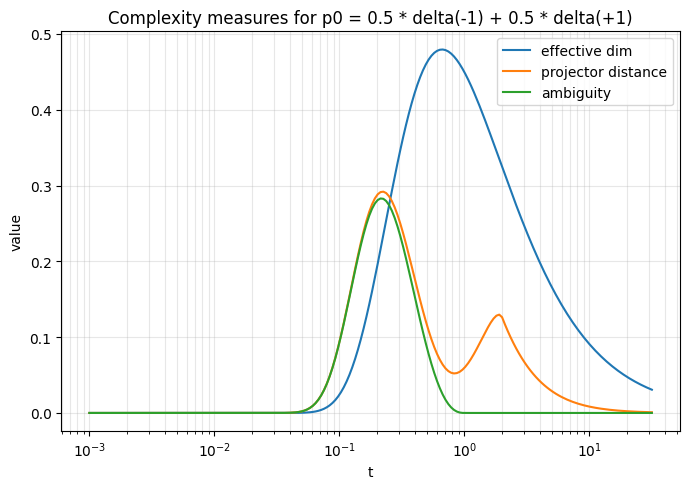

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")

# p0 = 0.5 delta_{-1} + 0.5 delta_{+1}, d=1
# closed form: m_t(y) = tanh(y/t), a(y,t) = A_t(y) = (1 - tanh(y/t)^2) / t
def a_of_y(y, t):
    return (1.0 - np.tanh(y / t) ** 2) / t

def p_t(y, t):
    return 0.5 * np.exp(-(y - 1) ** 2 / (2 * t)) / np.sqrt(2 * np.pi * t) \
         + 0.5 * np.exp(-(y + 1) ** 2 / (2 * t)) / np.sqrt(2 * np.pi * t)

def expectation(f, t, lim=None):
    lim = lim or (10 * np.sqrt(t) + 10)
    val, _ = quad(lambda y: f(y, t) * p_t(y, t), -lim, lim, limit=400, points=[-1, 1])
    return val

def d_eff(t):
    return expectation(lambda y, t: a_of_y(y, t), t)

def delta_proj(t):
    def f(y, t):
        a = a_of_y(y, t)
        return np.minimum(a ** 2, (a - 1) ** 2)
    return expectation(f, t)

def A_meas(t):
    def f(y, t):
        a = a_of_y(y, t)
        return np.maximum(a - 1, 0.0) ** 2
    return expectation(f, t)

ts = np.logspace(-3, 1.5, 200)
d_eff_vals = np.array([d_eff(t) for t in ts])
delta_proj_vals = np.array([delta_proj(t) for t in ts])
A_vals = np.array([A_meas(t) for t in ts])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts, d_eff_vals, label="effective dim")
ax.plot(ts, delta_proj_vals, label="projector distance")
ax.plot(ts, A_vals, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = 0.5 * delta(-1) + 0.5 * delta(+1)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

device: mps


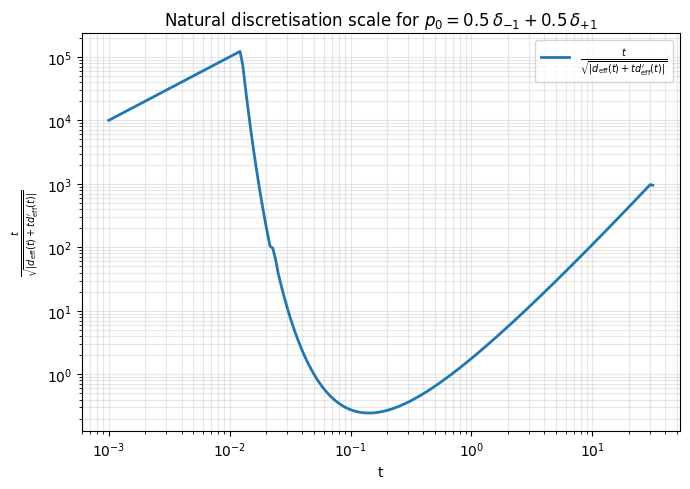

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")

# p0 = 0.5 delta_{-1} + 0.5 delta_{+1}, d=1
# closed form:
# m_t(y) = tanh(y/t)
# a(y,t) = A_t(y) = (1 - tanh(y/t)^2) / t

def a_of_y(y, t):
    return (1.0 - np.tanh(y / t) ** 2) / t

def p_t(y, t):
    return (
        0.5 * np.exp(-(y - 1) ** 2 / (2 * t)) / np.sqrt(2 * np.pi * t)
        + 0.5 * np.exp(-(y + 1) ** 2 / (2 * t)) / np.sqrt(2 * np.pi * t)
    )

def expectation(f, t, lim=None):
    lim = lim or (10 * np.sqrt(t) + 10)
    val, _ = quad(
        lambda y: f(y, t) * p_t(y, t),
        -lim,
        lim,
        limit=400,
        points=[-1, 1],
    )
    return val

def d_eff(t):
    return expectation(lambda y, t: a_of_y(y, t), t)

# Log-spaced time grid
ts = np.logspace(-3, 1.5, 200)

# Compute effective dimension
d_eff_vals = np.array([d_eff(t) for t in ts])

# Numerical derivative with respect to t
d_eff_prime_vals = np.gradient(d_eff_vals, ts, edge_order=2)

# Quantity:
# t / sqrt(|d_eff(t) + t d_eff'(t)|)
denom = np.abs(d_eff_vals + ts * d_eff_prime_vals)

# Avoid division by zero / numerical issues
eps = 1e-14
natural_dt_scale = ts / np.sqrt(np.maximum(denom, eps))

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    ts,
    natural_dt_scale,
    linewidth=2,
    label=r"$\frac{t}{\sqrt{|d_{\mathrm{eff}}(t)+t d_{\mathrm{eff}}'(t)|}}$"
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("t")
ax.set_ylabel(
    r"$\frac{t}{\sqrt{|d_{\mathrm{eff}}(t)+t d_{\mathrm{eff}}'(t)|}}$"
)
ax.set_title(
    r"Natural discretisation scale for "
    r"$p_0 = 0.5\,\delta_{-1} + 0.5\,\delta_{+1}$"
)

ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

device: mps


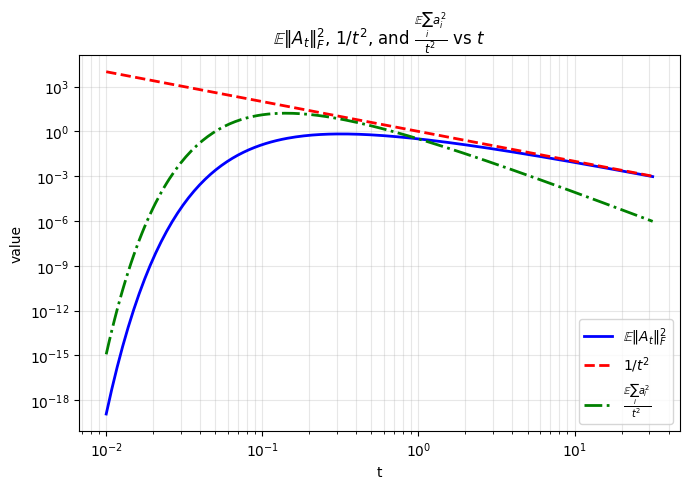

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
import torch

device = (
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"device: {device}")


# p0 = 0.5 delta_{-1} + 0.5 delta_{+1}, d=1
# closed form: m_t(y) = tanh(y/t), a(y,t) = A_t(y) = sech(y/t)^2 / t
def a_of_y(y, t):
  x = np.clip(y / t, -300, 300)
  return (1.0 / np.cosh(x) ** 2) / t


def p_t(y, t):
  return 0.5 * np.exp(-((y - 1) ** 2) / (2 * t)) / np.sqrt(
      2 * np.pi * t
  ) + 0.5 * np.exp(-((y + 1) ** 2) / (2 * t)) / np.sqrt(2 * np.pi * t)


def expectation(f, t, lim=None):
  lim = lim or (10 * np.sqrt(t) + 10)
  val, _ = quad(
      lambda y: f(y, t) * p_t(y, t), -lim, lim, limit=500, points=[-1, 0, 1]
  )
  return val


def frobenius_sq(t):
  return expectation(lambda y, t: a_of_y(y, t) ** 2, t)


ts = np.logspace(-2, 1.5, 200)

frob_vals = np.array([frobenius_sq(t) for t in ts])
line_1_over_t2 = 1.0 / (ts**2)
line_frob_over_t2 = frob_vals / (ts**2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts, frob_vals, label=r"$\mathbb{E}\|A_t\|_F^2$", color="blue", lw=2)
ax.plot(
    ts,
    line_1_over_t2,
    label=r"$1/t^2$",
    color="red",
    linestyle="--",
    lw=2,
)
ax.plot(
    ts,
    line_frob_over_t2,
    label=r"$\frac{\mathbb{E} \sum_i a_i^2}{t^2}$",
    color="green",
    linestyle="-.",
    lw=2,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title(
    r"$\mathbb{E}\|A_t\|_F^2$, $1/t^2$, and $\frac{\mathbb{E} \sum_i a_i^2}{t^2}$"
    r" vs $t$"
)
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Second example: uniform on the unit circle in $\mathbb R^2$

$p_0$ = uniform measure on $S^1 \subset \mathbb R^2$, $X = (\cos\theta,\sin\theta)$, $\theta \sim \mathrm{Unif}[0,2\pi)$. By rotational symmetry, for $y=(r,0)$ the posterior over $\theta$ is von Mises with mean direction $0$ and concentration $\kappa = r/t$:
$$
p(\theta \mid y) \propto \exp(\kappa \cos\theta).
$$
Writing $A_k(\kappa) = I_k(\kappa)/I_0(\kappa)$ (ratios of modified Bessel functions), $Cov(X\mid y)$ is diagonal in the normal/tangent basis at $x(0)=(1,0)$, with eigenvalues
$$
a_{\mathrm{normal}} = \frac{1}{t}\left[\frac{1+A_2(\kappa)}{2} - A_1(\kappa)^2\right], \qquad
a_{\mathrm{tangent}} = \frac{1}{t}\cdot\frac{1-A_2(\kappa)}{2}.
$$
Averaging over $Y_t$ (marginal radial density $p_t(r) \propto e^{-(r-1)^2/2t} I_0(r/t)$) gives the three measures exactly as in the two-point case.

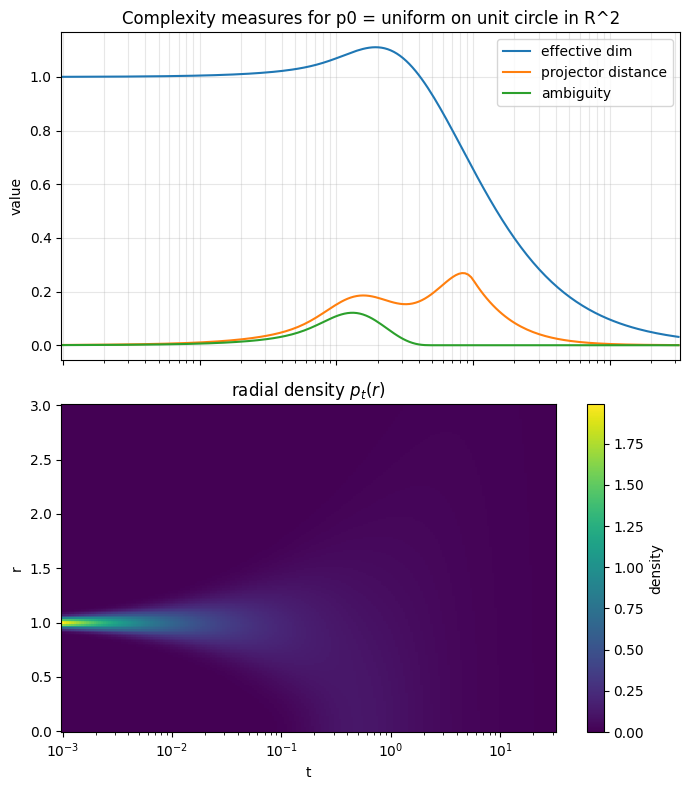

In [ ]:
from scipy.special import ive

# p0 = uniform on unit circle in R^2. For y = (r, 0), posterior over theta is
# von Mises(mu=0, kappa=r/t). a_normal, a_tangent below are the eigenvalues of
# A_t(y) in the normal/tangent basis at the nearest circle point.
def bessel_ratios(kappa):
    i0 = ive(0, kappa)
    i1 = ive(1, kappa)
    i2 = ive(2, kappa)
    return i1 / i0, i2 / i0  # A1(kappa), A2(kappa)  (exp factors cancel)

def eigs_circle(r, t):
    kappa = r / t
    A1, A2 = bessel_ratios(kappa)
    a_normal = ((1 + A2) / 2 - A1 ** 2) / t
    a_tangent = ((1 - A2) / 2) / t
    return a_normal, a_tangent

def p_t_radial(r, t):
    # marginal density of Y_t at radius r, using ive to avoid overflow in I_0
    return np.exp(-(r - 1) ** 2 / (2 * t)) * ive(0, r / t) / (2 * np.pi * t)

def expectation_circle(f, t, lim=None):
    lim = lim or (1 + 10 * np.sqrt(t) + 10)
    val, _ = quad(lambda r: f(r, t) * p_t_radial(r, t) * 2 * np.pi * r, 0, lim, limit=400, points=[1])
    return val

def d_eff_circle(t):
    return expectation_circle(lambda r, t: sum(eigs_circle(r, t)), t)

def delta_proj_circle(t):
    def f(r, t):
        an, at = eigs_circle(r, t)
        return min(an ** 2, (an - 1) ** 2) + min(at ** 2, (at - 1) ** 2)
    return expectation_circle(f, t)

def A_meas_circle(t):
    def f(r, t):
        an, at = eigs_circle(r, t)
        return max(an - 1, 0.0) ** 2 + max(at - 1, 0.0) ** 2
    return expectation_circle(f, t)

ts_c = np.logspace(-3, 1.5, 200)
d_eff_c = np.array([d_eff_circle(t) for t in ts_c])
delta_proj_c = np.array([delta_proj_circle(t) for t in ts_c])
A_c = np.array([A_meas_circle(t) for t in ts_c])

fig, (ax, ax_dens) = plt.subplots(2, 1, figsize=(7, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [1, 1]})
ax.plot(ts_c, d_eff_c, label="effective dim")
ax.plot(ts_c, delta_proj_c, label="projector distance")
ax.plot(ts_c, A_c, label="ambiguity")
ax.set_xscale("log")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = uniform on unit circle in R^2")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

r_grid = np.linspace(0, 3, 200)
TT, RR = np.meshgrid(ts_c, r_grid)
dens_c = p_t_radial(RR, TT)
mesh = ax_dens.pcolormesh(TT, RR, dens_c, shading="auto", cmap="viridis")
ax_dens.set_xscale("log")
ax_dens.set_xlabel("t")
ax_dens.set_ylabel("r")
ax_dens.set_title("radial density $p_t(r)$")
fig.colorbar(mesh, ax=ax_dens, label="density")

fig.tight_layout()
plt.show()

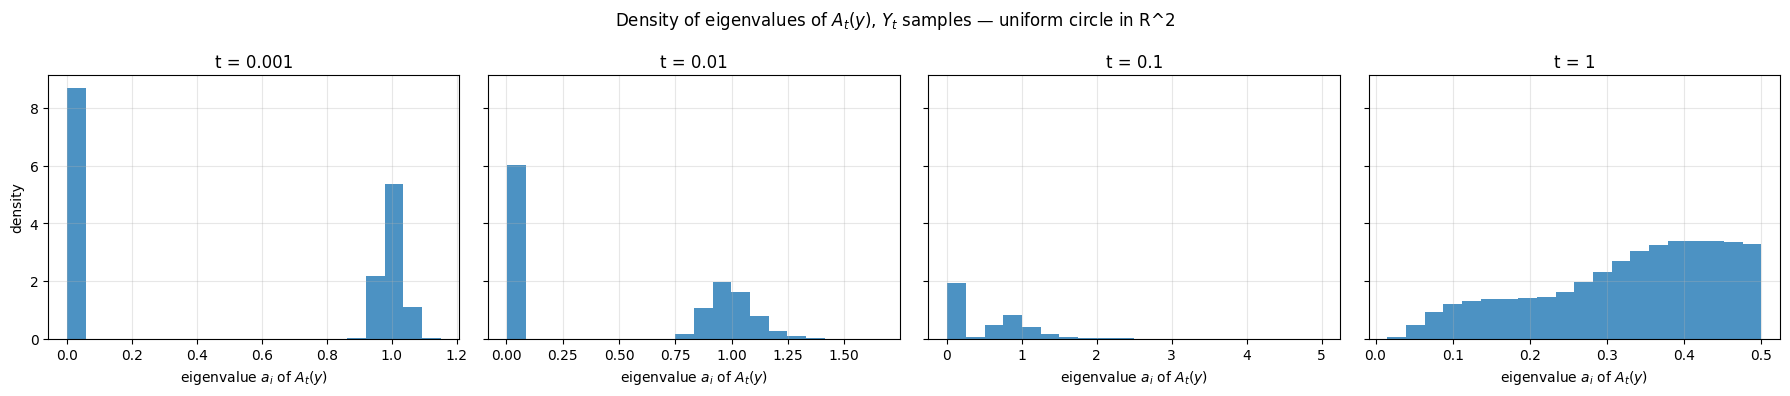

In [13]:
rng = np.random.default_rng(0)
N_eig = 200_000
theta0 = rng.uniform(0, 2 * np.pi, size=N_eig)
X0_circle = np.stack([np.cos(theta0), np.sin(theta0)], axis=1)
Z_circle = rng.standard_normal((N_eig, 2))

eig_ts = [1e-3, 1e-2, 1e-1, 1.0]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, t in zip(axes, eig_ts):
    Y = X0_circle + np.sqrt(t) * Z_circle
    r = np.linalg.norm(Y, axis=1)
    a_normal, a_tangent = eigs_circle(r, t)
    eigvals = np.concatenate([a_normal, a_tangent])
    ax.hist(eigvals, bins=20, density=True, color="tab:blue", alpha=0.8)
    ax.set_title(f"t = {t:g}")
    ax.set_xlabel(r"eigenvalue $a_i$ of $A_t(y)$")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("density")
fig.suptitle("Density of eigenvalues of $A_t(y)$, $Y_t$ samples — uniform circle in R^2")
fig.tight_layout()
plt.show()

## Third example: two circles in $\mathbb R^3$

$p_0 = \frac12 \mathrm{Unif}(C_-) + \frac12\mathrm{Unif}(C_+)$, where $C_\pm = \{x^2+y^2=1,\ z=\pm c\}$, $c=0.25$.

By rotational symmetry about the $z$-axis, fix $y=(r,0,z)$. Writing $X=(\cos\theta,\sin\theta,z_b)$ with $b\in\{-,+\}$, $z_b=\pm c$,
$$
\lVert y-X\rVert^2 = (r^2-2r\cos\theta+1) + (z-z_b)^2,
$$
so the posterior factorizes: $\theta \perp b \mid y$, with $\theta\mid y \sim \mathrm{VonMises}(0,\kappa=r/t)$ exactly as on the single circle (independent of $z$, $b$), and $b\mid y$ a two-point posterior in $z$ exactly as in the $\pm c$ toy example (independent of $r$, $\theta$).

Consequently $\operatorname{Cov}(X\mid y)$ is diagonal in the (planar-normal, planar-tangent, $z$) basis, with the first two eigenvalues identical to the single-circle case and the third identical to the two-point case with branch amplitude $c$ instead of $1$:
$$
a_{\mathrm{normal}}, a_{\mathrm{tangent}} \ \text{as before (function of } r/t\text{)}, \qquad
a_z(z,t) = \frac{c^2\big(1-\tanh^2(cz/t)\big)}{t}.
$$
Since $r\perp z$ given $y$, each of the three scalar measures is additive:
$$
d_{\mathrm{eff}} = d_{\mathrm{eff}}^{\mathrm{circle}} + d_{\mathrm{eff}}^{z}, \qquad
\Delta_{\mathrm{proj}} = \Delta_{\mathrm{proj}}^{\mathrm{circle}} + \Delta_{\mathrm{proj}}^{z}, \qquad
\mathcal A = \mathcal A^{\mathrm{circle}} + \mathcal A^{z},
$$
where the circle terms reuse the single-circle computation above and the $z$-terms reuse the two-point computation with branch amplitude $c=0.25$.

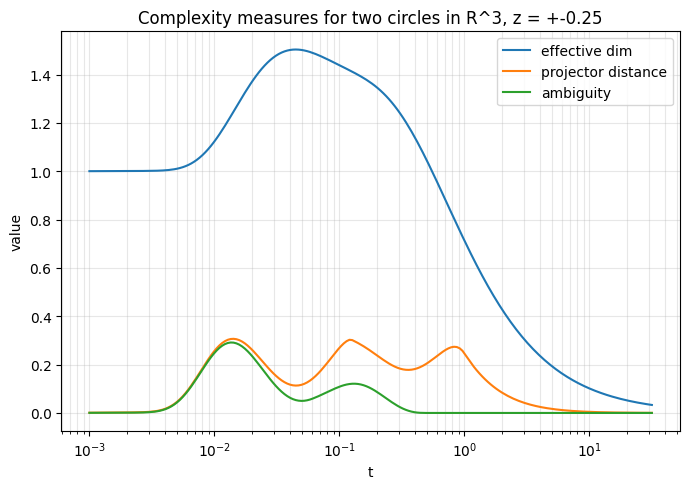

In [4]:
c = 0.25  # half-separation of the two circles along z

# z-branch eigenvalue and marginal density, generalizing the two-point example to branches +-c
def a_z_of_z(z, t, c):
    return c ** 2 * (1.0 - np.tanh(c * z / t) ** 2) / t

def p_z(z, t, c):
    return 0.5 * np.exp(-(z - c) ** 2 / (2 * t)) / np.sqrt(2 * np.pi * t) \
         + 0.5 * np.exp(-(z + c) ** 2 / (2 * t)) / np.sqrt(2 * np.pi * t)

def expectation_z(f, t, c, lim=None):
    lim = lim or (8 * np.sqrt(t) + 8 * c + 1)
    val, _ = quad(lambda z: f(z, t, c) * p_z(z, t, c), -lim, lim, limit=400, points=[-c, c])
    return val

def d_eff_z(t, c):
    return expectation_z(lambda z, t, c: a_z_of_z(z, t, c), t, c)

def delta_proj_z(t, c):
    def f(z, t, c):
        a = a_z_of_z(z, t, c)
        return min(a ** 2, (a - 1) ** 2)
    return expectation_z(f, t, c)

def A_meas_z(t, c):
    def f(z, t, c):
        a = a_z_of_z(z, t, c)
        return max(a - 1, 0.0) ** 2
    return expectation_z(f, t, c)

ts_2c = np.logspace(-3, 1.5, 200)
d_eff_2c = np.array([d_eff_circle(t) + d_eff_z(t, c) for t in ts_2c])
delta_proj_2c = np.array([delta_proj_circle(t) + delta_proj_z(t, c) for t in ts_2c])
A_2c = np.array([A_meas_circle(t) + A_meas_z(t, c) for t in ts_2c])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts_2c, d_eff_2c, label="effective dim")
ax.plot(ts_2c, delta_proj_2c, label="projector distance")
ax.plot(ts_2c, A_2c, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title(f"Complexity measures for two circles in R^3, z = +-{c}")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()


### Density of $Y_t$ in the plane $x=0$ (two-circle example)

Using $p_t(x,y,z) = p_r(r)\,p_z(z)$ with $r=\sqrt{x^2+y^2}$ (from the factorization above), restricting to $x=0$ gives $p_t(0,y,z) = p_r(|y|)\,p_z(z)$. Slider on $t$, log scale.

interactive(children=(FloatSlider(value=-2.0, description='log10(t)', max=1.0, min=-3.0, step=0.05), Output())…

<function __main__.update(log_t)>

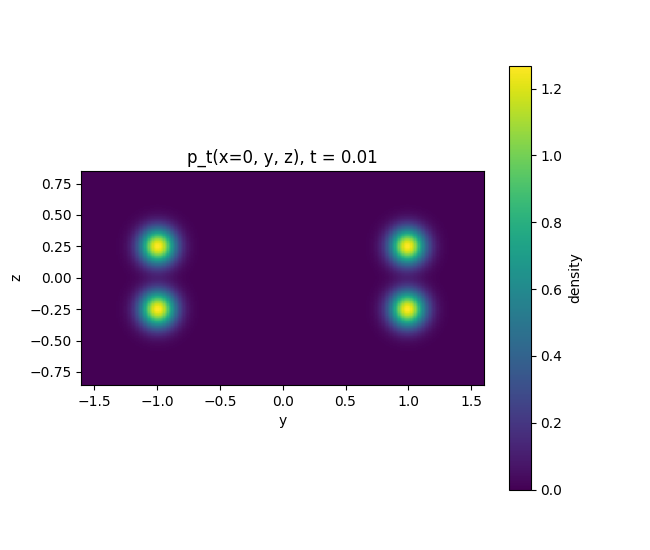

In [4]:
%matplotlib widget
import ipywidgets as widgets

N = 300

def make_grid(t):
    half_y = 1.0 + 6 * np.sqrt(t)
    half_z = c + 6 * np.sqrt(t)
    y_grid = np.linspace(-half_y, half_y, N)
    z_grid = np.linspace(-half_z, half_z, N)
    return np.meshgrid(y_grid, z_grid)

def density_x0(YC, ZC, t):
    return p_t_radial(np.abs(YC), t) * p_z(ZC, t, c)

t0 = 1e-2
YC, ZC = make_grid(t0)
dens0 = density_x0(YC, ZC, t0)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
mesh = ax.pcolormesh(YC, ZC, dens0, shading="nearest", cmap="viridis")
cbar = fig.colorbar(mesh, ax=ax, label="density")
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_title(f"p_t(x=0, y, z), t = {t0:.4g}")
ax.set_aspect("equal")

def update(log_t):
    t = 10 ** log_t
    YC, ZC = make_grid(t)
    dens = density_x0(YC, ZC, t)
    ax.clear()
    m = ax.pcolormesh(YC, ZC, dens, shading="nearest", cmap="viridis", vmin=0, vmax=dens.max())
    ax.set_xlabel("y")
    ax.set_ylabel("z")
    ax.set_title(f"p_t(x=0, y, z), t = {t:.4g}")
    ax.set_aspect("equal")
    cbar.update_normal(m)
    fig.canvas.draw_idle()

slider = widgets.FloatSlider(value=-2.0, min=-3.0, max=1.0, step=0.05,
                              description="log10(t)", continuous_update=True)
widgets.interact(update, log_t=slider)


## Fourth example: a cross (two crossing segments) in $\mathbb R^2$

$p_0 = \frac12\mathrm{Unif}[(-1,0),(1,0)] + \frac12\mathrm{Unif}[(0,-1),(0,1)]$. Conditional on branch, the posterior over the in-segment coordinate is a truncated Gaussian on $[-1,1]$ (closed form), and the branch posterior is a two-point mixture with logit $(y_1^2-y_2^2)/(2t) + \log Z_h(y_1,t) - \log Z_v(y_2,t)$, $Z$ the truncated-Gaussian normalizer. The law of total covariance gives $\operatorname{Cov}(X\mid y)$ in closed form; no rotational symmetry survives here, so the average over $Y_t$ is done by Monte Carlo (fixed base samples, noise scaled by $\sqrt t$, so the curves are smooth across $t$).

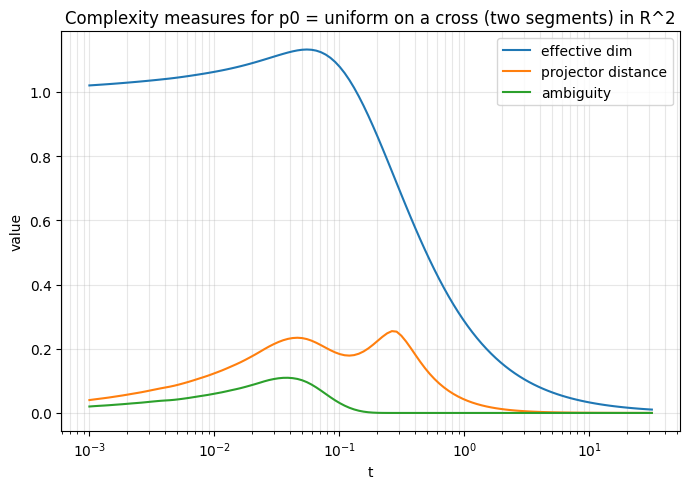

In [5]:
from scipy.special import ndtr, log_ndtr

_SQRT_2PI = np.sqrt(2 * np.pi)

def _phi(x):
    return np.exp(-0.5 * x ** 2) / _SQRT_2PI

def eig_cross(y1, y2, t):
    sig = np.sqrt(t)

    def branch_moments(y):
        a, b = (-1 - y) / sig, (1 - y) / sig
        Z = np.clip(ndtr(b) - ndtr(a), 1e-300, None)
        pa, pb = _phi(a), _phi(b)
        mean = y + sig * (pa - pb) / Z
        var = t * (1.0 + (a * pa - b * pb) / Z - ((pa - pb) / Z) ** 2)
        var = np.clip(var, 0.0, None)
        logZ = np.log(Z)
        return mean, var, logZ

    Eu_h, Var_u_h, logZ_h = branch_moments(y1)
    Ev_v, Var_v_v, logZ_v = branch_moments(y2)

    logit = (y1 ** 2 - y2 ** 2) / (2 * t) + logZ_h - logZ_v
    w_h = 1.0 / (1.0 + np.exp(-logit))
    w_v = 1.0 - w_h

    C11 = w_h * Var_u_h + w_h * w_v * Eu_h ** 2
    C22 = w_v * Var_v_v + w_h * w_v * Ev_v ** 2
    C12 = -w_h * w_v * Eu_h * Ev_v

    tr = C11 + C22
    det = C11 * C22 - C12 ** 2
    disc = np.sqrt(np.clip(tr ** 2 - 4 * det, 0, None))
    a1, a2 = (tr + disc) / (2 * t), (tr - disc) / (2 * t)
    return a1, a2

rng = np.random.default_rng(0)
N = 200_000
branch = rng.integers(0, 2, size=N)
coord = rng.uniform(-1, 1, size=N)
X = np.zeros((N, 2))
X[branch == 0, 0] = coord[branch == 0]
X[branch == 1, 1] = coord[branch == 1]
Z = rng.standard_normal((N, 2))

def measures_cross(t):
    Y = X + np.sqrt(t) * Z
    a1, a2 = eig_cross(Y[:, 0], Y[:, 1], t)
    d_eff = np.mean(a1 + a2)
    delta_proj = np.mean(np.minimum(a1 ** 2, (a1 - 1) ** 2) + np.minimum(a2 ** 2, (a2 - 1) ** 2))
    A = np.mean(np.maximum(a1 - 1, 0.0) ** 2 + np.maximum(a2 - 1, 0.0) ** 2)
    return d_eff, delta_proj, A

ts_x = np.logspace(-3, 1.5, 120)
d_eff_x, delta_proj_x, A_x = map(np.array, zip(*[measures_cross(t) for t in ts_x]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts_x, d_eff_x, label="effective dim")
ax.plot(ts_x, delta_proj_x, label="projector distance")
ax.plot(ts_x, A_x, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = uniform on a cross (two segments) in R^2")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()


## Fifth example: anisotropic Gaussian in $\mathbb R^3$

$p_0 = \mathcal N(0, \Sigma)$, $\Sigma = \operatorname{diag}(1, 4, 16)$. Gaussian posterior covariance doesn't depend on $y$, so $A_t$ is constant: eigenvalues $a_i(t) = s_i/(s_i+t)$ for $s_i \in \{1,4,16\}$. Since $a_i \in (0,1)$ always, ambiguity is identically 0 (closed form, no quadrature/MC needed).

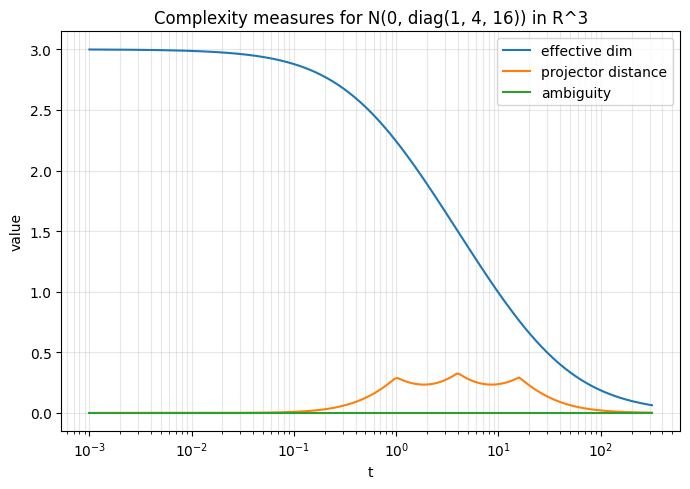

In [ ]:
Sigma_diag = np.array([1.0, 4.0, 16.0])

def a_gauss(t, s):
    return s / (s + t)

def d_eff_gauss(t):
    return np.sum(a_gauss(t, Sigma_diag))

def delta_proj_gauss(t):
    a = a_gauss(t, Sigma_diag)
    return np.sum(np.minimum(a ** 2, (a - 1) ** 2))

def A_meas_gauss(t):
    a = a_gauss(t, Sigma_diag)
    return np.sum(np.maximum(a - 1, 0.0) ** 2)

ts_g = np.logspace(-3, 2.5, 200)
d_eff_g = np.array([d_eff_gauss(t) for t in ts_g])
delta_proj_g = np.array([delta_proj_gauss(t) for t in ts_g])
A_g = np.array([A_meas_gauss(t) for t in ts_g])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts_g, d_eff_g, label="effective dim")
ax.plot(ts_g, delta_proj_g, label="projector distance")
ax.plot(ts_g, A_g, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for N(0, diag(1, 4, 16)) in R^3")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Sixth example: 12 equally spaced points on the unit circle in $\mathbb R^2$

$p_0 = \frac{1}{12}\sum_{k=0}^{11}\delta_{x_k}$, $x_k = (\cos\theta_k,\sin\theta_k)$, $\theta_k = 2\pi k/12$. Since $\lVert x_k\rVert=1$ for all $k$, the posterior is an exact softmax over the 12 points:
$$
w_k(y) = \frac{\exp(y^\top x_k / t)}{\sum_j \exp(y^\top x_j/t)}, \qquad m_t(y) = \sum_k w_k(y)\,x_k, \qquad \operatorname{Cov}(X\mid y) = \sum_k w_k(y)\,x_k x_k^\top - m_t(y) m_t(y)^\top.
$$
No continuous symmetry survives (only the 12-fold dihedral group), so unlike the single continuous circle the average over $Y_t$ is done by Monte Carlo, exactly as in the cross example — but here the inner posterior itself is exact (a finite softmax), not an approximation.

This example separates two length scales that coincide in the continuous-circle case: the point spacing ($2\sin(\pi/12)\approx 0.52$) and the manifold scale (radius $1$). Expect $d_{\mathrm{eff}}(t)\to 0$ at both $t\to0$ (posterior collapses to the nearest single point — a $0$-dimensional object) and $t\to\infty$ (posterior → uniform prior, bounded support), with a bump toward $d_{\mathrm{eff}}\approx1$ at intermediate $t$ where the noise blurs the points into an unresolved circle.

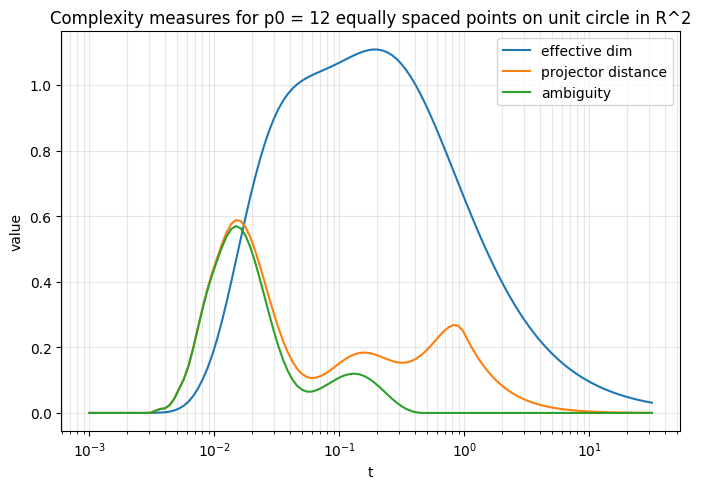

In [ ]:
n_pts = 12
thetas = 2 * np.pi * np.arange(n_pts) / n_pts
pts = np.stack([np.cos(thetas), np.sin(thetas)], axis=1)  # (12, 2)

def eig_points(y, t, pts):
    # y: (N, 2); posterior over the 12 points is an exact softmax since ||x_k|| = 1
    logits = (y @ pts.T) / t  # (N, 12)
    logits -= logits.max(axis=1, keepdims=True)
    w = np.exp(logits)
    w /= w.sum(axis=1, keepdims=True)

    m = w @ pts  # (N, 2)
    C11 = w @ pts[:, 0] ** 2 - m[:, 0] ** 2
    C22 = w @ pts[:, 1] ** 2 - m[:, 1] ** 2
    C12 = w @ (pts[:, 0] * pts[:, 1]) - m[:, 0] * m[:, 1]

    tr = C11 + C22
    det = C11 * C22 - C12 ** 2
    disc = np.sqrt(np.clip(tr ** 2 - 4 * det, 0, None))
    a1, a2 = (tr + disc) / (2 * t), (tr - disc) / (2 * t)
    return a1, a2

rng = np.random.default_rng(0)
N = 200_000
branch = rng.integers(0, n_pts, size=N)
X0 = pts[branch]
Z = rng.standard_normal((N, 2))

def measures_points(t):
    Y = X0 + np.sqrt(t) * Z
    a1, a2 = eig_points(Y, t, pts)
    d_eff = np.mean(a1 + a2)
    delta_proj = np.mean(np.minimum(a1 ** 2, (a1 - 1) ** 2) + np.minimum(a2 ** 2, (a2 - 1) ** 2))
    A = np.mean(np.maximum(a1 - 1, 0.0) ** 2 + np.maximum(a2 - 1, 0.0) ** 2)
    return d_eff, delta_proj, A

ts_p = np.logspace(-3, 1.5, 120)
d_eff_p, delta_proj_p, A_p = map(np.array, zip(*[measures_points(t) for t in ts_p]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts_p, d_eff_p, label="effective dim")
ax.plot(ts_p, delta_proj_p, label="projector distance")
ax.plot(ts_p, A_p, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = 12 equally spaced points on unit circle in R^2")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Seventh example: a 12×12 latitude/longitude grid on the unit sphere in $\mathbb R^3$

$p_0 = \frac{1}{144}\sum_{i,j} \delta_{x_{ij}}$, $x_{ij} = (\cos\phi_i\cos\lambda_j,\ \cos\phi_i\sin\lambda_j,\ \sin\phi_i)$, with 12 longitudes $\lambda_j = 2\pi j/12$ and 12 latitudes $\phi_i$ evenly spaced from $-90^\circ$ to $90^\circ$ inclusive. Since $\lVert x_{ij}\rVert=1$ for every grid point, the posterior is again an exact softmax exactly as in the 12-point-circle example, now over $M=144$ points in $\mathbb R^3$:
$$
w_{ij}(y) = \frac{\exp(y^\top x_{ij}/t)}{\sum_{i',j'}\exp(y^\top x_{i'j'}/t)}, \qquad \operatorname{Cov}(X\mid y) = \sum_{ij} w_{ij}(y)\,x_{ij}x_{ij}^\top - m_t(y)m_t(y)^\top \in \mathbb R^{3\times3}.
$$
Only the discrete symmetry group (12-fold rotation about $z$, reflection $z\mapsto-z$) survives, so the average over $Y_t$ is done by Monte Carlo as before; the three $3\times3$ eigenvalues are obtained numerically rather than via the closed-form $2\times2$ trace/det trick.

Note the lat/lon grid is not equal-area: all 12 longitude points collapse to the same location at each pole ($\phi=\pm90^\circ$), so the discrete measure concentrates $2/12$ of its mass at the two poles and spreads the rest thinly near the equator. Expect the same $0\to k\to0$ qualitative shape in $d_{\mathrm{eff}}(t)$ as the circle case, but now rising toward the sphere's intrinsic dimension $k=2$ at intermediate $t$, with extra structure from the pole/equator density mismatch.

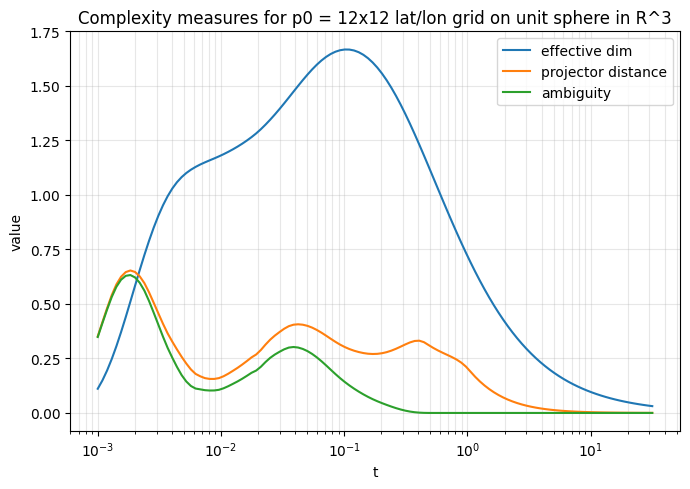

In [8]:
n_lon, n_lat = 6, 18
lons = 2 * np.pi * np.arange(n_lon) / n_lon
lats = np.linspace(-np.pi / 2, np.pi / 2, n_lat)
LAT, LON = np.meshgrid(lats, lons, indexing="ij")
pts_sphere = np.stack([
    np.cos(LAT) * np.cos(LON),
    np.cos(LAT) * np.sin(LON),
    np.sin(LAT),
], axis=-1).reshape(-1, 3)  # (144, 3)
pts_outer_flat = np.einsum("ki,kj->kij", pts_sphere, pts_sphere).reshape(pts_sphere.shape[0], 9)

def eig_points_3d(y, t, pts, outer_flat):
    # y: (N, 3); posterior over the 144 grid points is an exact softmax since ||x_k|| = 1
    logits = (y @ pts.T) / t  # (N, M)
    logits -= logits.max(axis=1, keepdims=True)
    w = np.exp(logits)
    w /= w.sum(axis=1, keepdims=True)

    m = w @ pts  # (N, 3)
    second = (w @ outer_flat).reshape(-1, 3, 3)  # sum_k w_k x_k x_k^T
    Cov = second - np.einsum("ni,nj->nij", m, m)
    A = Cov / t
    return np.linalg.eigvalsh(A)  # (N, 3), ascending

rng = np.random.default_rng(0)
N = 100_000
branch = rng.integers(0, pts_sphere.shape[0], size=N)
X0 = pts_sphere[branch]
Z = rng.standard_normal((N, 3))

def measures_sphere(t):
    Y = X0 + np.sqrt(t) * Z
    eigs = eig_points_3d(Y, t, pts_sphere, pts_outer_flat)
    d_eff = np.mean(eigs.sum(axis=1))
    delta_proj = np.mean(np.minimum(eigs ** 2, (eigs - 1) ** 2).sum(axis=1))
    A = np.mean((np.maximum(eigs - 1, 0.0) ** 2).sum(axis=1))
    return d_eff, delta_proj, A

ts_s = np.logspace(-3, 1.5, 120)
d_eff_s, delta_proj_s, A_s = map(np.array, zip(*[measures_sphere(t) for t in ts_s]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts_s, d_eff_s, label="effective dim")
ax.plot(ts_s, delta_proj_s, label="projector distance")
ax.plot(ts_s, A_s, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = 12x12 lat/lon grid on unit sphere in R^3")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Eighth example: non-uniform density on the unit circle in $\mathbb R^2$ (3:1 left/right mass)

$p_0$ has density (w.r.t. arc length) on $S^1$
$$
f(\theta) = \begin{cases} \frac{3}{4\pi}, & \cos\theta < 0 \ \text{(left half, } x<0\text{)} \\ \frac{1}{4\pi}, & \cos\theta > 0 \ \text{(right half, } x>0\text{)} \end{cases}
$$
so the left half carries $3\times$ the mass of the right half, each still uniform within its half. Only the reflection $y_2\mapsto -y_2$ survives as a symmetry (no rotational symmetry, unlike the uniform-circle example), so $y$ cannot be reduced to a radial coordinate.

The posterior over $\theta$ given $y$ is $p(\theta\mid y) \propto f(\theta)\exp(y^\top x(\theta)/t)$ (the $\lVert x(\theta)\rVert=1$ trick still kills the $\lVert x(\theta)\rVert^2$ term). This is evaluated by discretizing $\theta$ on a fine uniform grid (steps of $1^\circ$) and reusing the same exact-softmax / $2\times2$ trace-det eigenvalue trick as the 12-point circle example, with $f(\theta_k)\,d\theta$ playing the role of the (now non-uniform) prior mass at each grid point. The outer average over $Y_t$ is Monte Carlo, with $X$ sampled exactly from the piecewise-uniform law (not from the grid).

Since the manifold itself is still a plain circle, the small/intermediate-$t$ tangent-projector limit should look like the uniform case — but the *discontinuity* in $f$ at $\theta=\pm\pi/2$ acts like a local two-branch mixture of unequal weight, so expect a visible imprint on $\mathcal A(t)$ (and possibly $\Delta_{\mathrm{proj}}$) at the length scale where noise starts blurring across that jump, absent in the uniform-density circle example.

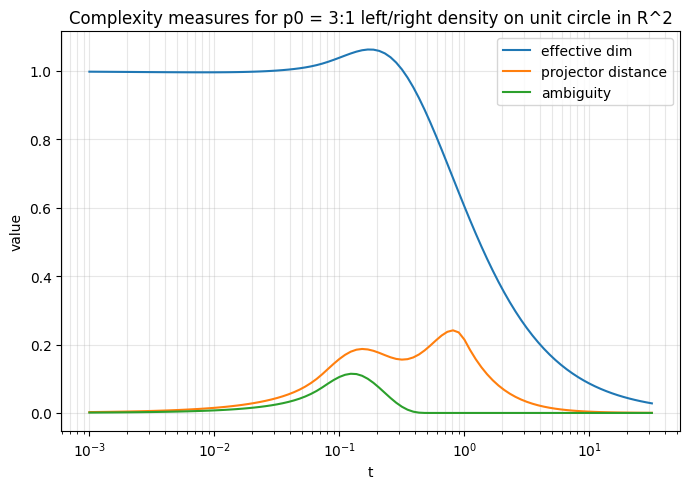

In [ ]:
M = 360  # quadrature grid over theta, 1-degree steps
d_theta = 2 * np.pi / M
theta_grid = (np.arange(M) + 0.5) * d_theta  # midpoints in [0, 2*pi)
x_grid = np.stack([np.cos(theta_grid), np.sin(theta_grid)], axis=1)  # (M, 2)

f_theta = np.where(np.cos(theta_grid) < 0, 3.0 / (4 * np.pi), 1.0 / (4 * np.pi))
log_mass = np.log(f_theta * d_theta)  # (M,), sums to ~1 after exponentiating

def eig_density_circle(y, t, x_grid, log_mass):
    # y: (N, 2); posterior over the grid is softmax(log_mass + y . x_k / t)
    logits = (y @ x_grid.T) / t + log_mass[None, :]  # (N, M)
    logits -= logits.max(axis=1, keepdims=True)
    w = np.exp(logits)
    w /= w.sum(axis=1, keepdims=True)

    m = w @ x_grid  # (N, 2)
    C11 = w @ x_grid[:, 0] ** 2 - m[:, 0] ** 2
    C22 = w @ x_grid[:, 1] ** 2 - m[:, 1] ** 2
    C12 = w @ (x_grid[:, 0] * x_grid[:, 1]) - m[:, 0] * m[:, 1]

    tr = C11 + C22
    det = C11 * C22 - C12 ** 2
    disc = np.sqrt(np.clip(tr ** 2 - 4 * det, 0, None))
    a1, a2 = (tr + disc) / (2 * t), (tr - disc) / (2 * t)
    return a1, a2

rng = np.random.default_rng(0)
N = 50_000
side = rng.random(N) < 0.75  # True -> left half (3/4 mass), False -> right half (1/4 mass)
theta0 = np.where(
    side,
    rng.uniform(np.pi / 2, 3 * np.pi / 2, size=N),
    rng.uniform(-np.pi / 2, np.pi / 2, size=N),
)
X0 = np.stack([np.cos(theta0), np.sin(theta0)], axis=1)
Z = rng.standard_normal((N, 2))

def measures_density_circle(t):
    Y = X0 + np.sqrt(t) * Z
    a1, a2 = eig_density_circle(Y, t, x_grid, log_mass)
    d_eff = np.mean(a1 + a2)
    delta_proj = np.mean(np.minimum(a1 ** 2, (a1 - 1) ** 2) + np.minimum(a2 ** 2, (a2 - 1) ** 2))
    A = np.mean(np.maximum(a1 - 1, 0.0) ** 2 + np.maximum(a2 - 1, 0.0) ** 2)
    return d_eff, delta_proj, A

ts_dc = np.logspace(-3, 1.5, 100)
d_eff_dc, delta_proj_dc, A_dc = map(np.array, zip(*[measures_density_circle(t) for t in ts_dc]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts_dc, d_eff_dc, label="effective dim")
ax.plot(ts_dc, delta_proj_dc, label="projector distance")
ax.plot(ts_dc, A_dc, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = 3:1 left/right density on unit circle in R^2")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Ninth example: a disjoint circle and 2-sphere in $\mathbb R^3$

$p_0 = \frac12\mathrm{Unif}(C) + \frac12\mathrm{Unif}(S)$, where $C$ is the unit circle centered at $(-2,0,0)$ lying in the $y$-$z$ plane, and $S$ is the unit 2-sphere centered at $(2,0,0)$ — a $1$-dimensional and a $2$-dimensional component, well separated (nearest-point gap $\approx 3.1$), each carrying half the mass.

Both branch posteriors are closed-form:
- **Circle branch**: writing $u=y_1+2$ (offset along the circle's normal axis) and $r=\sqrt{y_2^2+y_3^2}$, this is exactly the single-circle example ($\kappa=r/t$, von Mises posterior over $\theta$) crossed with a Gaussian in $u$ — $X_1=-2$ deterministically, so its posterior variance is $0$.
- **Sphere branch**: writing $\rho = \lVert y-(2,0,0)\rVert$, the posterior direction is von Mises–Fisher on $S^2$ with concentration $\kappa=\rho/t$. For $p=3$ the Bessel ratios collapse to elementary hyperbolic functions: mean resultant $A_1(\kappa)=\coth\kappa-\frac1\kappa$, radial (normal) variance $A_1'(\kappa)=\frac1{\kappa^2}-\frac1{\sinh^2\kappa}$, and the two tangential directions share variance $A_1(\kappa)/\kappa$. The branch marginal $p(y\mid S)$ also collapses to an elementary expression via $\sinh(\kappa) = \tfrac12(e^\kappa-e^{-\kappa})$, avoiding overflow at small $t$.

The branch posterior $w_c(y), w_s(y)$ (from the closed-form marginals $p(y\mid C)$, $p(y\mid S)$) and the law of total covariance combine the two branch-conditional means/covariances into $\operatorname{Cov}(X\mid y)$ exactly — no Monte Carlo needed for the inner posterior, only for the outer average over $Y_t$. Below the three complexity-measure curves, a $2\times2$ grid of 3D scatter plots shows the actual sampled $Y_t$ point clouds at $t=10^{-3},10^{-2},10^{-1},1$ (colored by true branch), for a direct visual of how the two components blur and eventually merge.

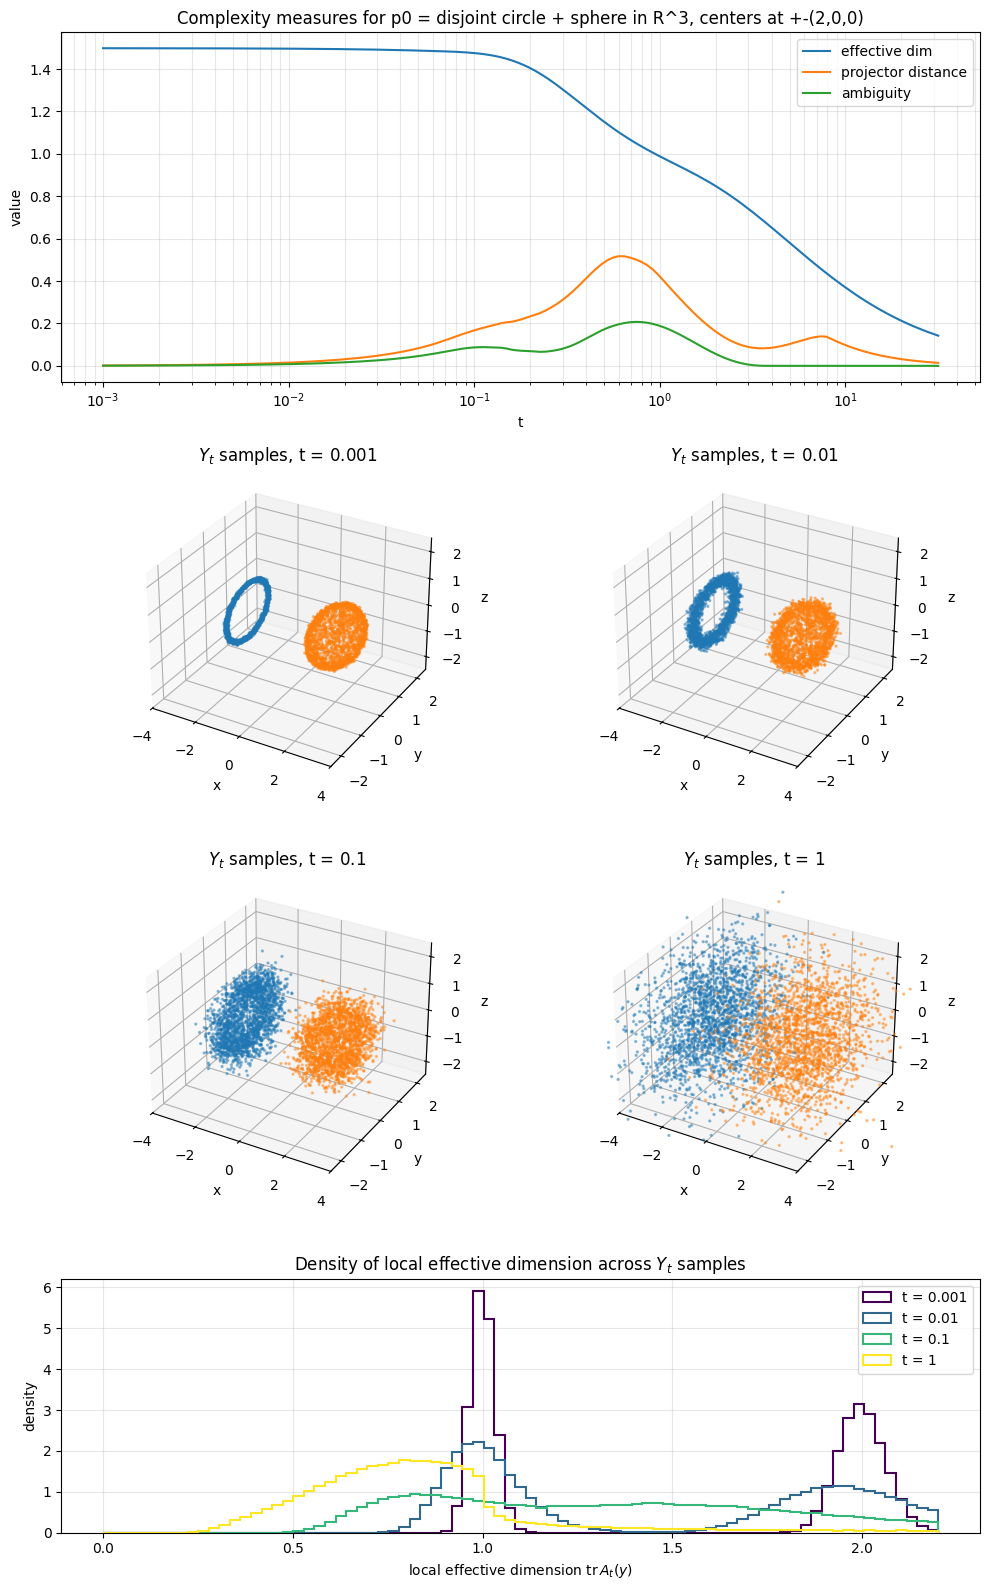

In [ ]:
c_circle = np.array([-2.0, 0.0, 0.0])
c_sphere = np.array([2.0, 0.0, 0.0])

def gaussian_log_pdf(u, t):
    return -0.5 * np.log(2 * np.pi * t) - u ** 2 / (2 * t)

def A1_sphere(k):
    k_safe = np.maximum(k, 1e-6)
    with np.errstate(over="ignore"):
        val = 1.0 / np.tanh(k_safe) - 1.0 / k_safe
    series = k / 3 - k ** 3 / 45
    return np.where(k < 1e-3, series, val)

def A1p_sphere(k):
    k_safe = np.maximum(k, 1e-6)
    with np.errstate(over="ignore"):
        val = 1.0 / k_safe ** 2 - 1.0 / np.sinh(k_safe) ** 2
    series = 1.0 / 3 - (2.0 / 15) * k ** 2
    return np.where(k < 1e-3, series, val)

def log_p_circle(Y, t):
    u1 = Y[:, 0] - c_circle[0]
    r1 = np.sqrt(Y[:, 1] ** 2 + Y[:, 2] ** 2)
    kappa = r1 / t
    log_ptr = -(r1 - 1) ** 2 / (2 * t) + np.log(ive(0, kappa)) - np.log(2 * np.pi * t)
    return log_ptr + gaussian_log_pdf(u1, t)

def log_p_sphere(Y, t):
    z = Y - c_sphere
    rho = np.sqrt(np.sum(z ** 2, axis=1))
    rho_safe = np.maximum(rho, 1e-12)
    a = -(rho - 1) ** 2 / (2 * t)
    log_diff = a + np.log1p(-np.exp(-2 * rho / t))
    return -1.5 * np.log(2 * np.pi * t) + np.log(t) - np.log(rho_safe) + np.log(0.5) + log_diff

def eigs_disjoint(Y, t):
    # returns (N, 3) eigenvalues of A_t(y) for the disjoint circle+sphere mixture
    u1 = Y[:, 0] - c_circle[0]
    r1 = np.sqrt(Y[:, 1] ** 2 + Y[:, 2] ** 2)
    r1_safe = np.maximum(r1, 1e-12)
    p_dir, q_dir = Y[:, 1] / r1_safe, Y[:, 2] / r1_safe
    kappa_c = r1 / t
    A1c, A2c = bessel_ratios(kappa_c)
    Cn_c = (1 + A2c) / 2 - A1c ** 2
    Ct_c = (1 - A2c) / 2
    mean_c = np.stack([np.full_like(u1, c_circle[0]), A1c * p_dir, A1c * q_dir], axis=1)
    Cov_c = np.zeros((Y.shape[0], 3, 3))
    Cov_c[:, 1, 1] = Cn_c * p_dir ** 2 + Ct_c * q_dir ** 2
    Cov_c[:, 2, 2] = Cn_c * q_dir ** 2 + Ct_c * p_dir ** 2
    Cov_c[:, 1, 2] = Cov_c[:, 2, 1] = (Cn_c - Ct_c) * p_dir * q_dir

    z = Y - c_sphere
    rho = np.sqrt(np.sum(z ** 2, axis=1))
    rho_safe = np.maximum(rho, 1e-12)
    psi = z / rho_safe[:, None]
    kappa_s = rho / t
    A1s = A1_sphere(kappa_s)
    A1ps = A1p_sphere(kappa_s)
    Ct_s = A1s / np.maximum(kappa_s, 1e-12)
    mean_s = c_sphere[None, :] + A1s[:, None] * psi
    eye = np.eye(3)[None, :, :]
    Cov_s = Ct_s[:, None, None] * eye + (A1ps - Ct_s)[:, None, None] * np.einsum("ni,nj->nij", psi, psi)

    logp_c = log_p_circle(Y, t)
    logp_s = log_p_sphere(Y, t)
    with np.errstate(over="ignore"):
        w_c = 1.0 / (1.0 + np.exp(-(logp_c - logp_s)))
    w_s = 1.0 - w_c

    mean_diff = mean_c - mean_s
    Cov_total = (w_c[:, None, None] * Cov_c + w_s[:, None, None] * Cov_s
                 + (w_c * w_s)[:, None, None] * np.einsum("ni,nj->nij", mean_diff, mean_diff))
    A = Cov_total / t
    return np.linalg.eigvalsh(A)  # (N, 3)

def measures_disjoint(Y, t):
    eigs = eigs_disjoint(Y, t)
    d_eff = eigs.sum(axis=1)
    delta_proj = np.minimum(eigs ** 2, (eigs - 1) ** 2).sum(axis=1)
    A_excess = (np.maximum(eigs - 1, 0.0) ** 2).sum(axis=1)
    return d_eff.mean(), delta_proj.mean(), A_excess.mean()

rng = np.random.default_rng(0)
N = 200_000
branch = rng.random(N) < 0.5  # True -> circle, False -> sphere
theta0 = rng.uniform(0, 2 * np.pi, size=N)
v0 = rng.standard_normal((N, 3))
v0 /= np.linalg.norm(v0, axis=1, keepdims=True)
X0 = np.where(
    branch[:, None],
    np.stack([np.full(N, c_circle[0]), np.cos(theta0), np.sin(theta0)], axis=1),
    c_sphere[None, :] + v0,
)
Z = rng.standard_normal((N, 3))

ts_ds = np.logspace(-3, 1.5, 150)
d_eff_ds, delta_proj_ds, A_ds = map(np.array, zip(
    *[measures_disjoint(X0 + np.sqrt(t) * Z, t) for t in ts_ds]))

fig = plt.figure(figsize=(10, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1.1, 1, 1, 0.8])
ax = fig.add_subplot(gs[0, :])
ax.plot(ts_ds, d_eff_ds, label="effective dim")
ax.plot(ts_ds, delta_proj_ds, label="projector distance")
ax.plot(ts_ds, A_ds, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = disjoint circle + sphere in R^3, centers at +-(2,0,0)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

n_plot = 4000
scatter_ts = [1e-3, 1e-2, 1e-1, 1.0]
colors = np.where(branch[:n_plot], "tab:blue", "tab:orange")
for i, t in enumerate(scatter_ts):
    ax3 = fig.add_subplot(gs[1 + i // 2, i % 2], projection="3d")
    Y_plot = X0[:n_plot] + np.sqrt(t) * Z[:n_plot]
    ax3.scatter(Y_plot[:, 0], Y_plot[:, 1], Y_plot[:, 2], s=2, alpha=0.4, c=colors)
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-2.5, 2.5)
    ax3.set_zlim(-2.5, 2.5)
    ax3.set_title(f"$Y_t$ samples, t = {t:g}")
    ax3.set_xlabel("x")
    ax3.set_ylabel("y")
    ax3.set_zlabel("z")

ax_hist = fig.add_subplot(gs[3, :])
cmap = plt.get_cmap("viridis")
bins = np.linspace(0, 2.2, 80)
for i, t in enumerate(scatter_ts):
    Y_full = X0 + np.sqrt(t) * Z
    d_local = eigs_disjoint(Y_full, t).sum(axis=1)
    ax_hist.hist(d_local, bins=bins, density=True, histtype="step", linewidth=1.5,
                 color=cmap(i / (len(scatter_ts) - 1)), label=f"t = {t:g}")
ax_hist.set_xlabel(r"local effective dimension $\operatorname{tr}A_t(y)$")
ax_hist.set_ylabel("density")
ax_hist.set_title("Density of local effective dimension across $Y_t$ samples")
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Tenth example: a Swiss roll in $\mathbb R^3$

$p_0$ = the standard Swiss roll, uniform in its own $(\varphi, h)$ parameters (not in surface area): $X = s\,(\varphi\cos\varphi,\ h,\ \varphi\sin\varphi)$, $\varphi\sim\mathrm{Unif}[1.5\pi, 4.5\pi]$, $h\sim\mathrm{Unif}[0,21]$, with scale $s=0.2$ bringing the roll down to the same order of magnitude as the other $\mathbb R^3$ examples. No symmetry survives (the surface has no isometries fixing a generic point's normal direction the way a sphere or circle does), so the posterior is approximated by discretizing $(\varphi,h)$ on a fine grid (a 2D quadrature analogous to the lat/lon-sphere and non-uniform-circle examples) and reusing the same softmax / law-of-total-covariance machinery, generalized to points that don't share a common norm (the disjoint circle+sphere example's $\lVert x_k\rVert^2$ correction term).

Because the grid is a finite approximation of a continuous surface, it has its own resolution scale (grid spacing $\sim0.1$ here). Below that scale the posterior behaves like a discrete point cloud rather than the true smooth surface — the same $d_{\mathrm{eff}}\to0$ collapse seen in the point-cloud circle/sphere examples — so expect a spurious dip near $t\sim10^{-3}\text{-}10^{-2}$ before $d_{\mathrm{eff}}$ recovers to $\approx2$ (a clean local surface) once $t$ is large enough to blur the grid but still much smaller than the sheet-to-sheet gap ($2\pi s\approx1.26$, from one full turn of $\varphi$). At larger $t$, noise starts bridging adjacent windings (a bump in $\mathcal A(t)$, and a second mode $>2$ in the local-dimension histogram where a point sits between two sheets), before everything collapses to one blob.

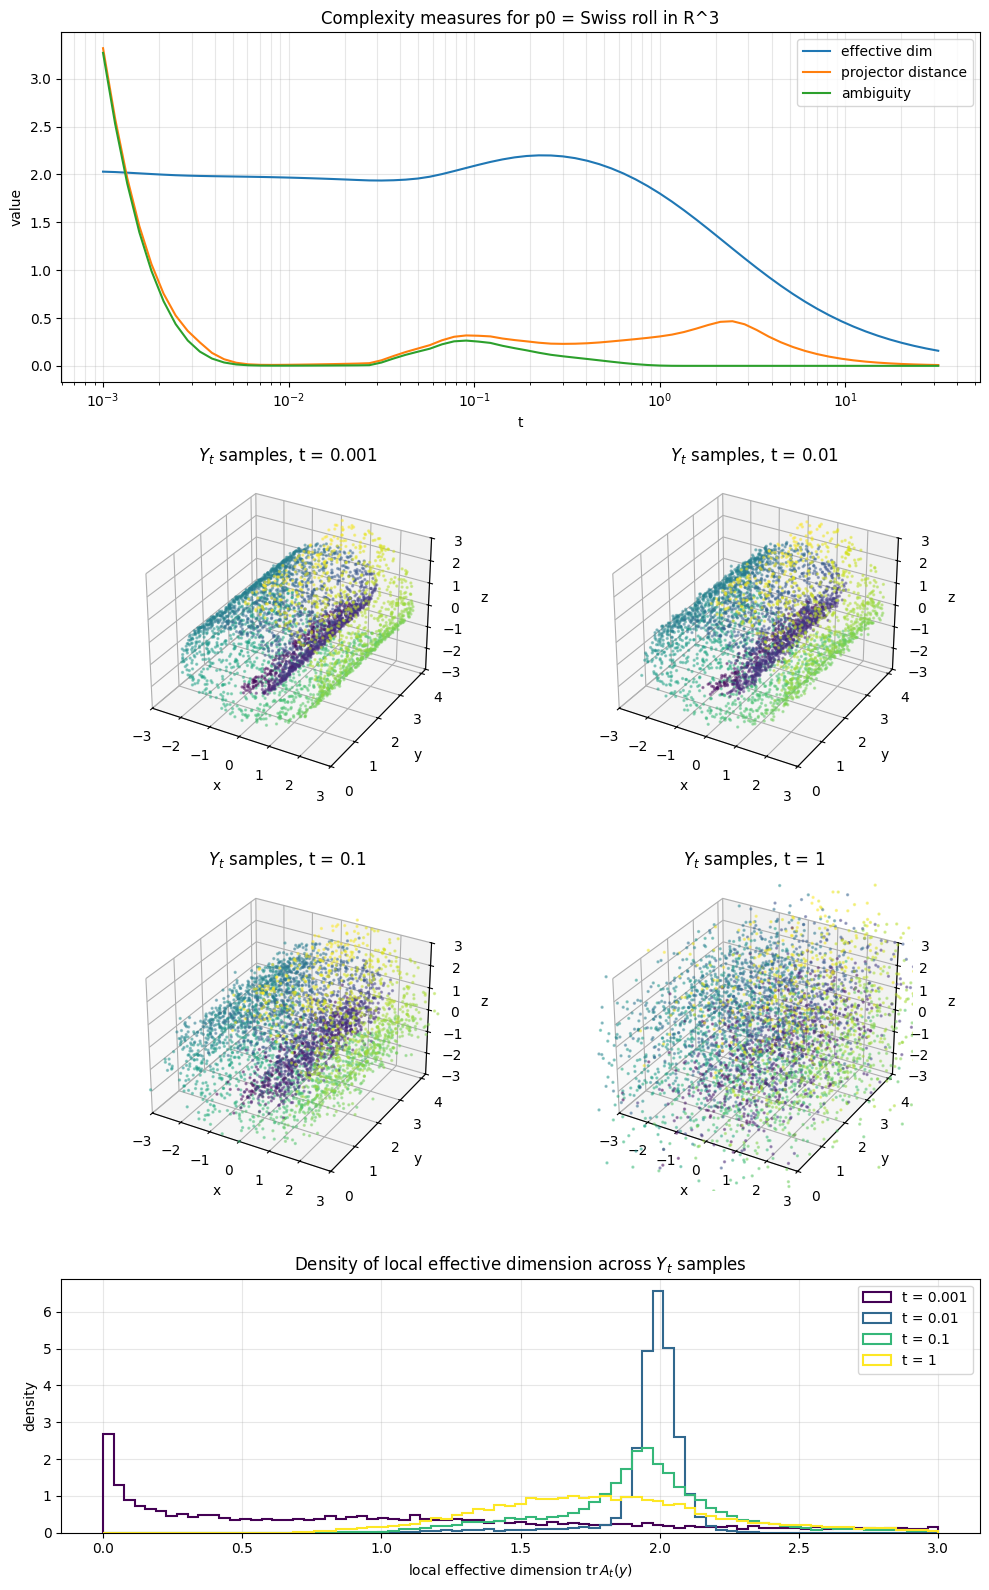

In [ ]:
roll_scale = 0.2
n_phi, n_h = 150, 30
phi_grid = np.linspace(1.5 * np.pi, 4.5 * np.pi, n_phi)
h_grid = np.linspace(0.0, 21.0, n_h)
PHI, H = np.meshgrid(phi_grid, h_grid, indexing="ij")
pts_roll = roll_scale * np.stack([PHI * np.cos(PHI), H, PHI * np.sin(PHI)], axis=-1).reshape(-1, 3)
pts_roll_sq = 0.5 * np.sum(pts_roll ** 2, axis=1)  # (M,)
pts_roll_outer_flat = np.einsum("ki,kj->kij", pts_roll, pts_roll).reshape(pts_roll.shape[0], 9)

def eigs_roll(y, t):
    # y: (N, 3); grid is a uniform-mass quadrature approximation of the Swiss roll
    logits = (y @ pts_roll.T - pts_roll_sq[None, :]) / t  # (N, M)
    logits -= logits.max(axis=1, keepdims=True)
    w = np.exp(logits)
    w /= w.sum(axis=1, keepdims=True)

    m = w @ pts_roll  # (N, 3)
    second = (w @ pts_roll_outer_flat).reshape(-1, 3, 3)
    Cov = second - np.einsum("ni,nj->nij", m, m)
    A = Cov / t
    return np.linalg.eigvalsh(A)  # (N, 3)

def measures_roll(Y, t):
    eigs = eigs_roll(Y, t)
    d_eff = eigs.sum(axis=1)
    delta_proj = np.minimum(eigs ** 2, (eigs - 1) ** 2).sum(axis=1)
    A_excess = (np.maximum(eigs - 1, 0.0) ** 2).sum(axis=1)
    return d_eff.mean(), delta_proj.mean(), A_excess.mean()

rng = np.random.default_rng(0)
N = 15_000
phi0 = rng.uniform(1.5 * np.pi, 4.5 * np.pi, size=N)
h0 = rng.uniform(0.0, 21.0, size=N)
X0 = roll_scale * np.stack([phi0 * np.cos(phi0), h0, phi0 * np.sin(phi0)], axis=1)
Z = rng.standard_normal((N, 3))

ts_r = np.logspace(-3, 1.5, 70)
d_eff_r, delta_proj_r, A_r = map(np.array, zip(
    *[measures_roll(X0 + np.sqrt(t) * Z, t) for t in ts_r]))

fig = plt.figure(figsize=(10, 16))
gs = fig.add_gridspec(4, 2, height_ratios=[1.1, 1, 1, 0.8])
ax = fig.add_subplot(gs[0, :])
ax.plot(ts_r, d_eff_r, label="effective dim")
ax.plot(ts_r, delta_proj_r, label="projector distance")
ax.plot(ts_r, A_r, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title("Complexity measures for p0 = Swiss roll in R^3")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

n_plot = 4000
scatter_ts = [1e-3, 1e-2, 1e-1, 1.0]
for i, t in enumerate(scatter_ts):
    ax3 = fig.add_subplot(gs[1 + i // 2, i % 2], projection="3d")
    Y_plot = X0[:n_plot] + np.sqrt(t) * Z[:n_plot]
    ax3.scatter(Y_plot[:, 0], Y_plot[:, 1], Y_plot[:, 2], s=2, alpha=0.4, c=phi0[:n_plot], cmap="viridis")
    ax3.set_xlim(-3, 3)
    ax3.set_ylim(0, 4.2)
    ax3.set_zlim(-3, 3)
    ax3.set_title(f"$Y_t$ samples, t = {t:g}")
    ax3.set_xlabel("x")
    ax3.set_ylabel("y")
    ax3.set_zlabel("z")

ax_hist = fig.add_subplot(gs[3, :])
cmap = plt.get_cmap("viridis")
bins = np.linspace(0, 3.0, 80)
for i, t in enumerate(scatter_ts):
    Y_full = X0 + np.sqrt(t) * Z
    d_local = eigs_roll(Y_full, t).sum(axis=1)
    ax_hist.hist(d_local, bins=bins, density=True, histtype="step", linewidth=1.5,
                 color=cmap(i / (len(scatter_ts) - 1)), label=f"t = {t:g}")
ax_hist.set_xlabel(r"local effective dimension $\operatorname{tr}A_t(y)$")
ax_hist.set_ylabel("density")
ax_hist.set_title("Density of local effective dimension across $Y_t$ samples")
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Eleventh example: real data — MNIST digit "1"s in $\mathbb R^{784}$

$p_0 \approx \frac1N\sum_i \delta_{x_i}$, the empirical measure over MNIST images of the digit 1 (flattened to $784$-dim, pixels in $[0,1]$), a genuinely high-dimensional finite point cloud with unknown intrinsic dimension (style variation: slant, thickness, stroke curvature). Exactly the finite-point-cloud formula used for the earlier point examples: $w_i(y) \propto \exp(-\lVert y-x_i\rVert^2/2t)$, $\mu_t(y)=\sum_i w_i x_i$, $\Sigma_t(y)=\sum_i w_i (x_i-\mu_t)(x_i-\mu_t)^\top$.

Unlike the low-dimensional toy examples, forming $\Sigma_t(y)$ as a full $784\times784$ matrix per sample and computing its full eigenspectrum ($\Delta_{\mathrm{proj}}$, $\mathcal A$ need more than the trace) is the computational bottleneck, so: the reference cloud is subsampled to $N=2000$ images for feasibility, the outer average over $Y_t$ uses a modest number of Monte Carlo draws per $t$, and the line-plot sweep uses well under 70 $t$-values. All three quantities reduce to matrix algebra ($\mu_t(y)=W X$, $\Sigma_t(y) = X_c^\top(w\odot X_c)$, eigenvalues via `eigvalsh`) — no explicit loop over reference points. No scatter plot (784-dim points don't project meaningfully to 3 axes); instead, as with the Swiss roll, a density-of-local-effective-dimension histogram at $t=10^{-3},10^{-2},10^{-1},10^0$ shows the distribution behind the mean curve.

digit-1 images available: 7877
variance explained by top 75 components: 0.954


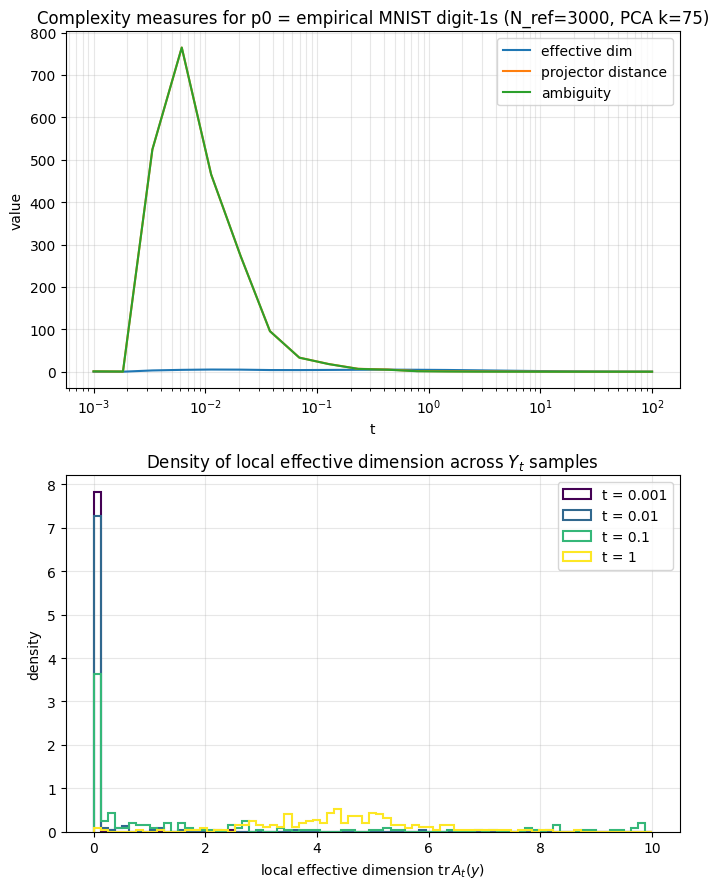

In [ ]:
from sklearn.datasets import fetch_openml

mnist_X, mnist_y = fetch_openml(
    "mnist_784", version=1, return_X_y=True, as_frame=False,
    data_home="/private/tmp/claude-501/-Users-danielgagliardi-Documents-GitHub-Latent-Diffusion-Geometry-PCB/a9ce17e1-f40d-4444-adc9-fc5fa6248001/scratchpad/mnist_cache",
)
ones = mnist_X[mnist_y == "1"].astype(np.float64) / 255.0  # (n_ones, 784), pixels in [0,1]
print(f"digit-1 images available: {ones.shape[0]}")

rng = np.random.default_rng(0)
mean_img = ones.mean(axis=0)

# PCA to k dims: an orthogonal projection leaves isotropic noise isotropic, and the
# discarded (~4% variance) residual is essentially the same for every data point, so
# it contributes an additive, i-independent term to ||y - x_i||^2 that cancels exactly
# in the softmax weights. Working entirely in this k-dim basis makes the (d, d)
# covariance + eigh per MC sample cheap (d = 75 instead of 784).
k = 75
_, S, Vt = np.linalg.svd(ones[:3000] - mean_img, full_matrices=False)
components = Vt[:k]  # (k, 784)
print(f"variance explained by top {k} components: {np.sum(S[:k] ** 2) / np.sum(S ** 2):.3f}")

N_ref = 3000
ref_idx = rng.choice(ones.shape[0], size=N_ref, replace=False)
X_ref = (ones[ref_idx] - mean_img) @ components.T  # (N_ref, k), the empirical measure's atoms
x_ref_sq = np.sum(X_ref ** 2, axis=1)
d = k

def eigs_mnist(Y, t):
    # Y: (M, k) in PCA coordinates; returns (M, d) eigenvalues of A_t(y)
    d2 = (np.sum(Y ** 2, axis=1, keepdims=True) - 2 * Y @ X_ref.T + x_ref_sq[None, :])  # (M, N_ref)
    logits = -d2 / (2 * t)
    logits -= logits.max(axis=1, keepdims=True)
    w = np.exp(logits)
    w /= w.sum(axis=1, keepdims=True)  # (M, N_ref)

    mu = w @ X_ref  # (M, d)
    eigs = np.empty((Y.shape[0], d))
    for m in range(Y.shape[0]):
        Xc = X_ref - mu[m]  # (N_ref, d)
        Cov = Xc.T @ (w[m][:, None] * Xc)  # (d, d)
        eigs[m] = np.linalg.eigvalsh(Cov) / t
    return eigs

def measures_mnist(Y, t):
    eigs = eigs_mnist(Y, t)
    d_eff = eigs.sum(axis=1)
    delta_proj = np.minimum(eigs ** 2, (eigs - 1) ** 2).sum(axis=1)
    A_excess = (np.maximum(eigs - 1, 0.0) ** 2).sum(axis=1)
    return d_eff.mean(), delta_proj.mean(), A_excess.mean()

n_sample_pool = 500
sample_idx = rng.choice(ones.shape[0], size=n_sample_pool, replace=False)
X0_mnist = (ones[sample_idx] - mean_img) @ components.T  # (n_sample_pool, k)
Z_mnist = rng.standard_normal(X0_mnist.shape)  # isotropic noise, restricted to the PCA subspace

ts_m = np.logspace(-3, 2, 20)  # well under 70 t-values
M_curve = 150  # MC draws per t for the line plot
d_eff_m, delta_proj_m, A_m = map(np.array, zip(
    *[measures_mnist(X0_mnist[:M_curve] + np.sqrt(t) * Z_mnist[:M_curve], t) for t in ts_m]))

scatter_ts = [1e-3, 1e-2, 1e-1, 1.0]
M_hist = 200

fig, (ax, ax_hist) = plt.subplots(2, 1, figsize=(7, 9), gridspec_kw={"height_ratios": [1, 1]})
ax.plot(ts_m, d_eff_m, label="effective dim")
ax.plot(ts_m, delta_proj_m, label="projector distance")
ax.plot(ts_m, A_m, label="ambiguity")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel("value")
ax.set_title(f"Complexity measures for p0 = empirical MNIST digit-1s (N_ref={N_ref}, PCA k={k})")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

cmap = plt.get_cmap("viridis")
bins = np.linspace(0, 10, 80)
for i, t in enumerate(scatter_ts):
    Y_full = X0_mnist[:M_hist] + np.sqrt(t) * Z_mnist[:M_hist]
    d_local = eigs_mnist(Y_full, t).sum(axis=1)
    ax_hist.hist(d_local, bins=bins, density=True, histtype="step", linewidth=1.5,
                 color=cmap(i / (len(scatter_ts) - 1)), label=f"t = {t:g}")
ax_hist.set_xlabel(r"local effective dimension $\operatorname{tr}A_t(y)$")
ax_hist.set_ylabel("density")
ax_hist.set_title("Density of local effective dimension across $Y_t$ samples")
ax_hist.legend()
ax_hist.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

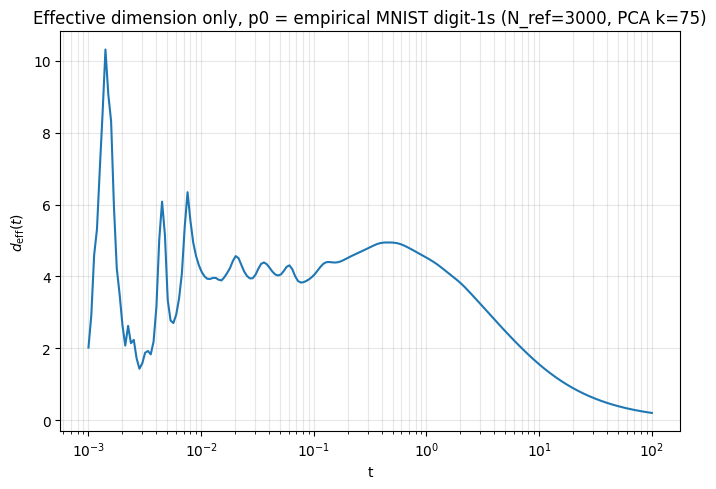

In [ ]:
def d_eff_only_mnist(Y, t):
    # trace(Cov(X|y)) = E[||X||^2|y] - ||mu(y)||^2, fully vectorized, no eigh needed
    d2 = (np.sum(Y ** 2, axis=1, keepdims=True) - 2 * Y @ X_ref.T + x_ref_sq[None, :])  # (M, N_ref)
    logits = -d2 / (2 * t)
    logits -= logits.max(axis=1, keepdims=True)
    w = np.exp(logits)
    w /= w.sum(axis=1, keepdims=True)  # (M, N_ref)

    Ex2 = w @ x_ref_sq  # (M,)
    mu = w @ X_ref  # (M, d)
    tr = Ex2 - np.sum(mu ** 2, axis=1)
    return tr / t  # (M,)

ts_trace = np.logspace(-3, 2, 200)  # much finer than the full 3-metric sweep, since this is cheap
M_trace = 300
d_eff_trace = np.array([
    d_eff_only_mnist(X0_mnist[:M_trace] + np.sqrt(t) * Z_mnist[:M_trace], t).mean()
    for t in ts_trace
])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ts_trace, d_eff_trace, color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("t")
ax.set_ylabel(r"$d_{\mathrm{eff}}(t)$")
ax.set_title(f"Effective dimension only, p0 = empirical MNIST digit-1s (N_ref={N_ref}, PCA k={k})")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

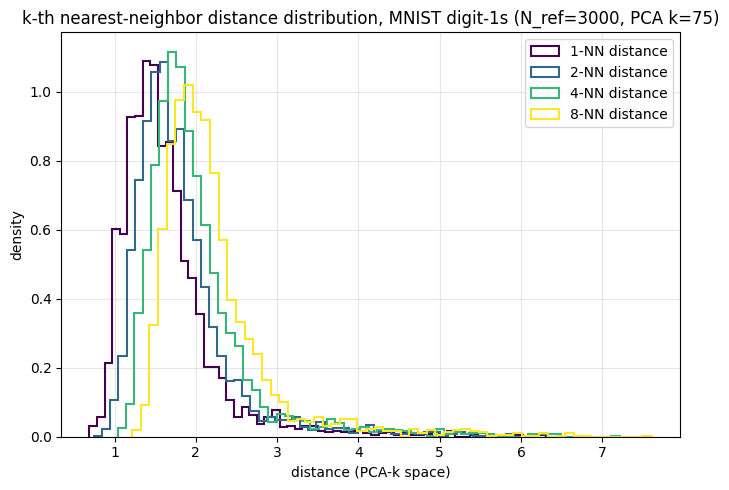

In [ ]:
from sklearn.neighbors import NearestNeighbors

ks = [1, 2, 4, 8]
nbrs = NearestNeighbors(n_neighbors=max(ks) + 1).fit(X_ref)  # +1 since a point is its own nearest neighbor
nn_dist, _ = nbrs.kneighbors(X_ref)  # (N_ref, max(ks)+1), column 0 is self (distance 0)

fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.get_cmap("viridis")
for i, kk in enumerate(ks):
    ax.hist(nn_dist[:, kk], bins=60, density=True, histtype="step", linewidth=1.5,
            color=cmap(i / (len(ks) - 1)), label=f"{kk}-NN distance")
ax.set_xlabel("distance (PCA-k space)")
ax.set_ylabel("density")
ax.set_title(f"k-th nearest-neighbor distance distribution, MNIST digit-1s (N_ref={N_ref}, PCA k={k})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()